#  Phase 3: Classification — FD001


---
# Step 0: Setup — Config, Folders, and Random Seed

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Manual config — since we're inside notebooks/phase3, go two levels up
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
REPORT_DIR = os.path.join(BASE_DIR, 'report')
CLASSIF_REPORT_DIR = os.path.join(REPORT_DIR, 'classification', 'FD001')  # ✅ New subfolder

RANDOM_STATE = 42  # Global seed

# Set consistent plotting aesthetics
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Set reproducibility
np.random.seed(RANDOM_STATE)

# Create required folders
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(CLASSIF_REPORT_DIR, exist_ok=True)

# Confirm setup
print(f" Figures directory ready: {FIGURES_DIR}")
print(f" Models directory ready: {MODELS_DIR}")
print(f" Classification report directory ready: {CLASSIF_REPORT_DIR}")
print(f" Random seed set: {RANDOM_STATE}")
print("✅ Step 0 complete — Phase 3 (FD001) setup initialized.\n")


 Figures directory ready: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3
 Models directory ready: c:\Users\pandr\hybrid-predictive-maintenance\models
 Classification report directory ready: c:\Users\pandr\hybrid-predictive-maintenance\report\classification\FD001
 Random seed set: 42
✅ Step 0 complete — Phase 3 (FD001) setup initialized.



# Step 1: Load Cleaned + Final Cluster-Labeled FD001 Dataset


In [5]:
import pandas as pd
import os

# Define BASE_DIR relative to this notebook location
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

# File path to labeled FD001 dataset
DATA_FILE_FD001 = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD001.csv')

# Load the dataset
df_fd001 = pd.read_csv(DATA_FILE_FD001)
print(f" FD001 dataset loaded from: {DATA_FILE_FD001}")

# --- Validate structure ---
assert 'final_stage' in df_fd001.columns, "'final_stage' column missing in dataset."

# Show head of the dataset
print("\n Preview — First 5 rows:")
print(df_fd001.head())

# Dataset information
print("\nℹ Dataset Info:")
print(df_fd001.info())

# Check for missing values
nulls = df_fd001.isnull().sum()
if nulls.any():
    print("\n Missing values found:")
    print(nulls[nulls > 0])
else:
    print("\n No missing values.")

# Class distribution (0–4 stages)
print("\n Final Stage Distribution (Count per Class):")
print(df_fd001['final_stage'].value_counts().sort_index())


 FD001 dataset loaded from: c:\Users\pandr\hybrid-predictive-maintenance\data\corrected_clustered_train_FD001.csv

 Preview — First 5 rows:
   unit  time  op_setting_1  op_setting_2  op_setting_3  sensor_2  sensor_3  \
0     1     1       -0.0007       -0.0004         100.0  0.183735  0.406802   
1     1     2        0.0019       -0.0003         100.0  0.283133  0.453019   
2     1     3       -0.0043        0.0003         100.0  0.343373  0.369523   
3     1     4        0.0007        0.0000         100.0  0.343373  0.256159   
4     1     5       -0.0019       -0.0002         100.0  0.349398  0.257467   

   sensor_4  sensor_6  sensor_7  ...  sensor_17  sensor_20  sensor_21  \
0  0.309757       1.0  0.726248  ...   0.333333   0.713178   0.724662   
1  0.352633       1.0  0.628019  ...   0.333333   0.666667   0.731014   
2  0.370527       1.0  0.710145  ...   0.166667   0.627907   0.621375   
3  0.331195       1.0  0.740741  ...   0.333333   0.573643   0.662386   
4  0.404625       1.

# Step 2: Feature and target setup

In [6]:
# Feature and target setup
df = df_fd001.copy()

# ✅ Dynamically select all usable sensor columns
selected_features = [col for col in df.columns if col.startswith("sensor_")]

# Extract features and target
X_fd001 = df[selected_features]
y_fd001 = df['final_stage']

# Display shapes and stats
print(f"✅ Selected features: {len(selected_features)} sensors → {selected_features}")
print("🔹 Input Features (X) shape:", X_fd001.shape)
print("🔹 Target (y) shape:", y_fd001.shape)

# Basic stats
print("\n📊 Feature Stats Summary:")
print(X_fd001.describe())

# Target class distribution
print("\n📊 Class Distribution in y:")
print(y_fd001.value_counts())


✅ Selected features: 15 sensors → ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
🔹 Input Features (X) shape: (20631, 15)
🔹 Target (y) shape: (20631,)

📊 Feature Stats Summary:
           sensor_2      sensor_3      sensor_4      sensor_6      sensor_7  \
count  20631.000000  20631.000000  20631.000000  20631.000000  20631.000000   
mean       0.443052      0.424746      0.450435      0.980321      0.566459   
std        0.150618      0.133664      0.151935      0.138898      0.142527   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.335843      0.331807      0.339467      1.000000      0.476651   
50%        0.430723      0.415522      0.435348      1.000000      0.578100   
75%        0.539157      0.508829      0.545324      1.000000      0.669887   
max        1.000000      1.000000      1.000000   

# Step 3: Label Encoding + Stratified Train-Test Split

In [7]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Step 3A: Engine-Wise Stratified Train-Test Split — FD001 Classification

#  Map each engine ID to its first degradation stage
engine_stage_map = df_fd001.groupby('unit')['final_stage'].first()

#  Unique engines and corresponding first-stage labels
unique_units = engine_stage_map.index
first_stage_labels = engine_stage_map.values

#  Stratified train-test engine split (80/20)
train_units, val_units = train_test_split(
    unique_units,
    test_size=0.2,
    stratify=first_stage_labels,  # ensures class balance across engines
    random_state=RANDOM_STATE
)

#  Filter full-cycle data for each engine set
train_df = df_fd001[df_fd001['unit'].isin(train_units)].reset_index(drop=True)
val_df = df_fd001[df_fd001['unit'].isin(val_units)].reset_index(drop=True)

#  Extract input features and class labels
X_train_fd001 = train_df[selected_features]
y_train_fd001 = train_df['final_stage']

X_val_fd001 = val_df[selected_features]
y_val_fd001 = val_df['final_stage']

#  Summary
print(" Train Set Shape:", X_train_fd001.shape, f"→ Unique Units: {train_df['unit'].nunique()}")
print(" Validation Set Shape:", X_val_fd001.shape, f"→ Unique Units: {val_df['unit'].nunique()}")

print("\n Train Final Stage Distribution:")
print(y_train_fd001.value_counts(normalize=True).sort_index().apply(lambda x: f"{x:.2%}"))

print("\n Validation Final Stage Distribution:")
print(y_val_fd001.value_counts(normalize=True).sort_index().apply(lambda x: f"{x:.2%}"))


 Train Set Shape: (16361, 15) → Unique Units: 80
 Validation Set Shape: (4270, 15) → Unique Units: 20

 Train Final Stage Distribution:
final_stage
0     5.27%
1    10.32%
2    26.04%
3    33.46%
4    24.90%
Name: proportion, dtype: object

 Validation Final Stage Distribution:
final_stage
0     7.89%
1     7.07%
2    22.06%
3    35.83%
4    27.14%
Name: proportion, dtype: object


# Step 4: Train & Evaluate Random Forest Classifier

RF 5-Fold CV F1 Scores: [0.9419756  0.94273597 0.93683332 0.93892929 0.95111689]
RF Mean F1 Score: 0.9423

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       337
           1       0.97      0.95      0.96       302
           2       0.91      0.93      0.92       942
           3       0.94      0.93      0.94      1530
           4       0.96      0.97      0.97      1159

    accuracy                           0.94      4270
   macro avg       0.95      0.95      0.95      4270
weighted avg       0.94      0.94      0.94      4270

Stage 3 F1 Score: 0.9389
Stage 4 F1 Score: 0.9655


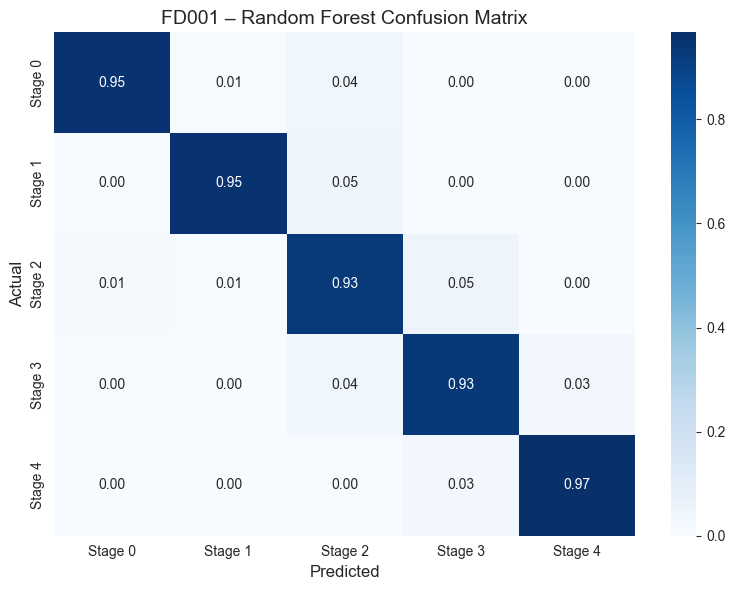

Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\rf_classifier_fd001.pkl
Confusion matrix saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd001_confusion_matrix.png
Prediction log saved: c:\Users\pandr\hybrid-predictive-maintenance\report\classification\FD001\predictions_fd001_rf.csv
Misclassified samples saved: c:\Users\pandr\hybrid-predictive-maintenance\report\classification\FD001\misclassified_fd001_rf.csv


In [11]:
# Step 4: Train & Evaluate Random Forest Classifier – FD001 (All Sensors, Correct Paths)

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_PATH = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD001.csv')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD001')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Load Data ---
df = pd.read_csv(DATA_PATH)

# ✅ Use all usable sensor columns
sensor_cols = [col for col in df.columns if col.startswith("sensor_")]
X = df[sensor_cols]
y = df['final_stage']  # This is already integer-labeled (0 to 4)

# --- Engine-wise Stratified Split ---
unit_ids = df['unit'].unique()
train_units, test_units = train_test_split(
    unit_ids,
    test_size=0.2,
    stratify=df.groupby('unit')['final_stage'].first(),
    random_state=RANDOM_STATE
)

train_df = df[df['unit'].isin(train_units)]
test_df = df[df['unit'].isin(test_units)]

X_train = train_df[sensor_cols]
y_train = train_df['final_stage']
X_test = test_df[sensor_cols]
y_test = test_df['final_stage']

# --- Random Forest Model ---
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# --- Cross-Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1_weighted')
print("RF 5-Fold CV F1 Scores:", cv_scores)
print("RF Mean F1 Score: {:.4f}".format(cv_scores.mean()))

# --- Train + Predict ---
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
proba = rf.predict_proba(X_test)
stage4_idx = list(rf.classes_).index(4)
prob_stage4 = proba[:, stage4_idx]
confidence = proba.max(axis=1)

# --- Evaluation ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
report = classification_report(y_test, y_pred, output_dict=True)

# ✅ Use string keys to access stage-wise F1 scores
print(f"Stage 3 F1 Score: {report['3']['f1-score']:.4f}")
print(f"Stage 4 F1 Score: {report['4']['f1-score']:.4f}")


# --- Confusion Matrix ---
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=[f"Stage {i}" for i in labels],
            yticklabels=[f"Stage {i}" for i in labels])
plt.title("FD001 – Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

# --- Save Outputs ---
model_path = os.path.join(MODELS_DIR, 'rf_classifier_fd001.pkl')
conf_matrix_path = os.path.join(FIGURES_DIR, 'rf_fd001_confusion_matrix.png')
joblib.dump(rf, model_path)
plt.savefig(conf_matrix_path)
plt.show() 
plt.close()
print(f"Model saved to: {model_path}")
print(f"Confusion matrix saved to: {conf_matrix_path}")

# --- Save Logs ---
test_df = test_df.reset_index(drop=True)
test_df['y_true'] = y_test.values
test_df['y_pred'] = y_pred
test_df['prob_stage4'] = prob_stage4
test_df['confidence'] = confidence

pred_log = os.path.join(REPORT_DIR, 'predictions_fd001_rf.csv')
misclassified_log = os.path.join(REPORT_DIR, 'misclassified_fd001_rf.csv')
test_df.to_csv(pred_log, index=False)
test_df[test_df['y_true'] != test_df['y_pred']].to_csv(misclassified_log, index=False)

print(f"Prediction log saved: {pred_log}")
print(f"Misclassified samples saved: {misclassified_log}")


# Step 5: SVM Classifier + Cross-Validation + Evaluation

SVM 5-Fold CV Weighted F1 Scores: [0.97958168 0.98870658 0.97893005 0.9787159  0.98508524]
SVM Mean F1 Score: 0.9822

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       337
           1       0.96      0.99      0.97       302
           2       0.99      0.97      0.98       942
           3       1.00      0.98      0.99      1530
           4       0.99      1.00      0.99      1159

    accuracy                           0.99      4270
   macro avg       0.98      0.99      0.98      4270
weighted avg       0.99      0.99      0.99      4270

Stage 3 F1 Score: 0.9911
Stage 4 F1 Score: 0.9931


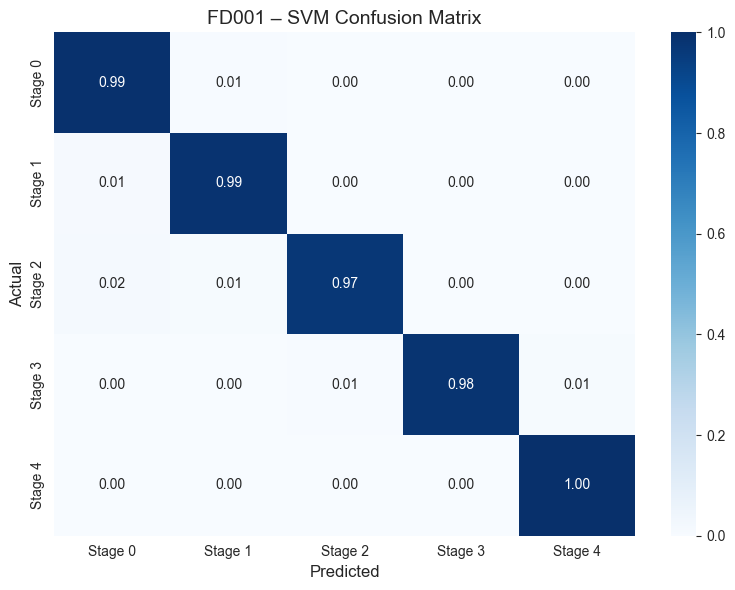

✅ All outputs saved for SVM Classifier (FD001).


In [12]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_PATH = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD001.csv')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD001')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Load Data ---
df_fd001 = pd.read_csv(DATA_PATH)
selected_features = [col for col in df_fd001.columns if col.startswith("sensor_")]
X = df_fd001[selected_features]
y = df_fd001['final_stage']

# --- Engine-wise Split ---
units = df_fd001['unit'].unique()
train_units, test_units = train_test_split(
    units,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_fd001.groupby('unit')['final_stage'].first()
)
train_df = df_fd001[df_fd001['unit'].isin(train_units)]
test_df = df_fd001[df_fd001['unit'].isin(test_units)]

X_train = train_df[selected_features]
y_train = train_df['final_stage']
X_test = test_df[selected_features]
y_test = test_df['final_stage']

# --- Model ---
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced',
              probability=True, random_state=RANDOM_STATE)

# --- CV ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(svm_clf, X_train, y_train, cv=cv, scoring='f1_weighted')
print("SVM 5-Fold CV Weighted F1 Scores:", scores)
print("SVM Mean F1 Score: {:.4f}".format(scores.mean()))

# --- Train ---
svm_clf.fit(X_train, y_train)

# --- Predict ---
y_pred = svm_clf.predict(X_test)
proba = svm_clf.predict_proba(X_test)
stage4_idx = list(svm_clf.classes_).index(4)
prob_stage4 = proba[:, stage4_idx]
confidence = proba.max(axis=1)

# --- Evaluation ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
report = classification_report(y_test, y_pred, output_dict=True)
print(f"Stage 3 F1 Score: {report['3']['f1-score']:.4f}")
print(f"Stage 4 F1 Score: {report['4']['f1-score']:.4f}")

# --- Confusion Matrix ---
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f"Stage {l}" for l in labels],
            yticklabels=[f"Stage {l}" for l in labels])
plt.title("FD001 – SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

# --- Save ---
joblib.dump(svm_clf, os.path.join(MODELS_DIR, 'svm_classifier_fd001.pkl'))
plt.savefig(os.path.join(FIGURES_DIR, 'svm_fd001_confusion_matrix.png'))
plt.show() 
plt.close()

df_log = test_df.reset_index(drop=True).copy()
df_log['y_true'] = y_test.values
df_log['y_pred'] = y_pred
df_log['prob_Stage4'] = prob_stage4
df_log['confidence'] = confidence
df_log.to_csv(os.path.join(REPORT_DIR, 'predictions_fd001_svm.csv'), index=False)
df_log[df_log['y_true'] != df_log['y_pred']].to_csv(os.path.join(REPORT_DIR, 'misclassified_fd001_svm.csv'), index=False)

print("✅ All outputs saved for SVM Classifier (FD001).")


# Step 6: Logistic Regression Classifier

LR 5-Fold CV F1 Scores: [0.9701143  0.98234278 0.97064185 0.97200323 0.97872766]
LR Mean F1 Score: 0.9748

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       337
           1       0.95      0.99      0.97       302
           2       0.97      0.95      0.96       942
           3       1.00      0.97      0.98      1530
           4       0.98      1.00      0.99      1159

    accuracy                           0.98      4270
   macro avg       0.96      0.98      0.97      4270
weighted avg       0.98      0.98      0.98      4270

Stage 3 F1 Score: 0.9841
Stage 4 F1 Score: 0.9902


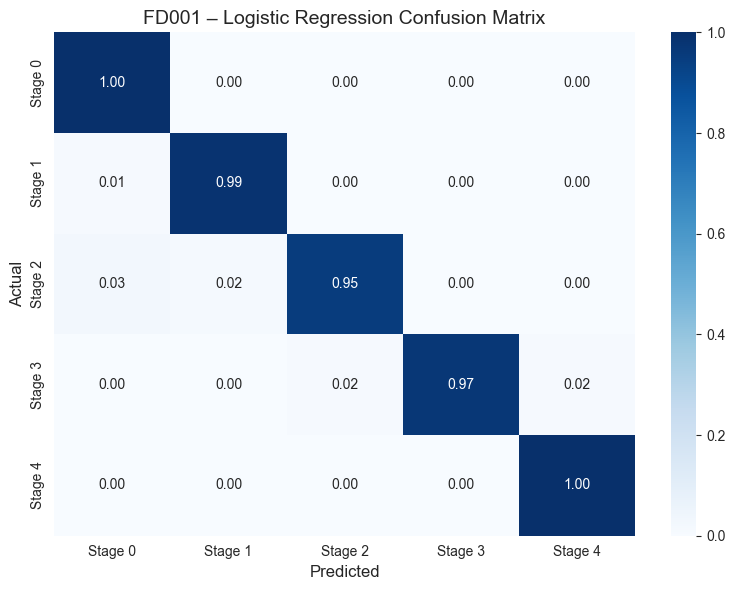

✅ Logistic Regression model, logs, and plots saved for FD001.


In [13]:
# Step 6: Logistic Regression Classifier — FD001 (All Sensors, Correct Paths)

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_PATH = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD001.csv')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD001')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Load Data ---
df_fd001 = pd.read_csv(DATA_PATH)
selected_features = [col for col in df_fd001.columns if col.startswith("sensor_")]
X = df_fd001[selected_features]
y = df_fd001['final_stage']

# --- Engine-wise Stratified Split ---
units = df_fd001['unit'].unique()
train_units, test_units = train_test_split(
    units,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_fd001.groupby('unit')['final_stage'].first()
)
train_df = df_fd001[df_fd001['unit'].isin(train_units)]
test_df = df_fd001[df_fd001['unit'].isin(test_units)]

X_train = train_df[selected_features]
y_train = train_df['final_stage']
X_test = test_df[selected_features]
y_test = test_df['final_stage']

# --- Model ---
lr_clf = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE
)


# --- CV ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(lr_clf, X_train, y_train, cv=cv, scoring='f1_weighted')
print("LR 5-Fold CV F1 Scores:", cv_scores)
print("LR Mean F1 Score: {:.4f}".format(cv_scores.mean()))

# --- Train ---
lr_clf.fit(X_train, y_train)

# --- Predict ---
y_pred = lr_clf.predict(X_test)
proba = lr_clf.predict_proba(X_test)
stage4_idx = list(lr_clf.classes_).index(4)
prob_stage4 = proba[:, stage4_idx]
confidence = proba.max(axis=1)

# --- Evaluate ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
report = classification_report(y_test, y_pred, output_dict=True)
print(f"Stage 3 F1 Score: {report['3']['f1-score']:.4f}")
print(f"Stage 4 F1 Score: {report['4']['f1-score']:.4f}")

# --- Confusion Matrix ---
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f"Stage {l}" for l in labels],
            yticklabels=[f"Stage {l}" for l in labels])
plt.title("FD001 – Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

# --- Save Model and Plot ---
model_path = os.path.join(MODELS_DIR, 'logreg_classifier_fd001.pkl')
fig_path = os.path.join(FIGURES_DIR, 'logreg_fd001_confusion_matrix.png')
joblib.dump(lr_clf, model_path)
plt.savefig(fig_path)
plt.show() 
plt.close()

# --- Logs ---
log_df = test_df.reset_index(drop=True).copy()
log_df['y_true'] = y_test.values
log_df['y_pred'] = y_pred
log_df['prob_Stage4'] = prob_stage4
log_df['confidence'] = confidence
log_df.to_csv(os.path.join(REPORT_DIR, 'predictions_fd001_logreg.csv'), index=False)
log_df[log_df['y_true'] != log_df['y_pred']].to_csv(os.path.join(REPORT_DIR, 'misclassified_fd001_logreg.csv'), index=False)

print("✅ Logistic Regression model, logs, and plots saved for FD001.")


# Step 7: XGBoost Classifier

XGBoost Label Mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}
XGBoost 5-Fold CV F1 Scores: [0.95115669 0.95727081 0.94814244 0.95175239 0.95907358]
XGBoost CV Mean F1 Score: 0.9535

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       337
           1       0.97      0.95      0.96       302
           2       0.93      0.94      0.94       942
           3       0.95      0.95      0.95      1530
           4       0.97      0.97      0.97      1159

    accuracy                           0.96      4270
   macro avg       0.96      0.95      0.96      4270
weighted avg       0.96      0.96      0.96      4270

Stage 3 F1 Score: 0.9520
Stage 4 F1 Score: 0.9719


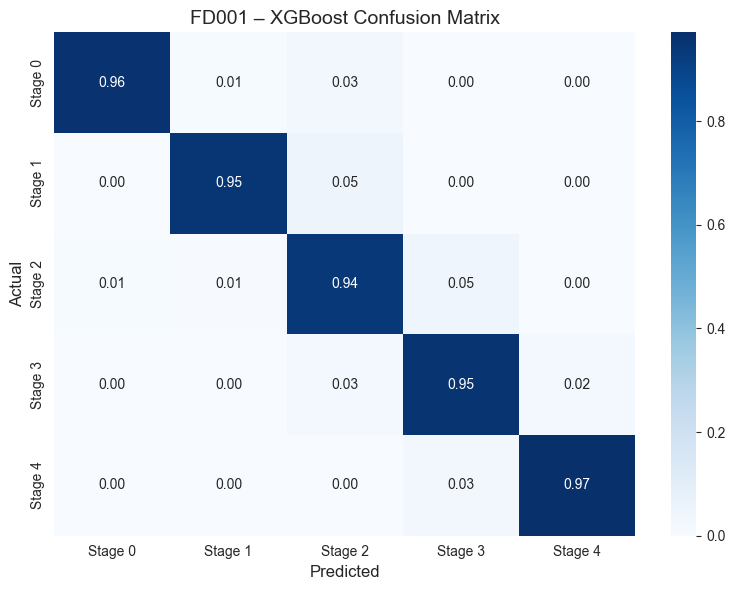

✅ XGBoost model, logs, and plots saved for FD001.


In [14]:
# Step 7: XGBoost Classifier — FD001 (All Sensors, Correct Paths)

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_PATH = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD001.csv')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD001')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Load and Prepare Data ---
df_fd001 = pd.read_csv(DATA_PATH)
selected_features = [col for col in df_fd001.columns if col.startswith("sensor_")]
X = df_fd001[selected_features]
y = df_fd001['final_stage']

# --- Engine-wise Stratified Split ---
units = df_fd001['unit'].unique()
train_units, test_units = train_test_split(
    units,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_fd001.groupby('unit')['final_stage'].first()
)
train_df = df_fd001[df_fd001['unit'].isin(train_units)]
test_df = df_fd001[df_fd001['unit'].isin(test_units)]

X_train = train_df[selected_features]
y_train = train_df['final_stage']
X_test = test_df[selected_features]
y_test = test_df['final_stage']

# --- Label Encoding ---
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
stage_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("XGBoost Label Mapping:", stage_map)

# --- Model ---
xgb_clf = XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    verbosity=0
)

# --- Cross-Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
xgb_cv_scores = cross_val_score(xgb_clf, X_train, y_train_enc, cv=cv, scoring='f1_weighted')
print("XGBoost 5-Fold CV F1 Scores:", xgb_cv_scores)
print("XGBoost CV Mean F1 Score: {:.4f}".format(xgb_cv_scores.mean()))

# --- Train ---
xgb_clf.fit(X_train, y_train_enc)

# --- Predict ---
y_pred_enc = xgb_clf.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)
y_true = le.inverse_transform(y_test_enc)

# --- Probabilities ---
proba = xgb_clf.predict_proba(X_test)
stage4_index = list(le.classes_).index(4)
prob_stage4 = proba[:, stage4_index]
confidence = proba.max(axis=1)

# --- Evaluation ---
print("\nXGBoost Classification Report:")
print(classification_report(y_true, y_pred))
report = classification_report(y_true, y_pred, output_dict=True)
print(f"Stage 3 F1 Score: {report['3']['f1-score']:.4f}")
print(f"Stage 4 F1 Score: {report['4']['f1-score']:.4f}")

# --- Confusion Matrix ---
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_test_enc, y_pred_enc, labels=labels, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f"Stage {l}" for l in labels],
            yticklabels=[f"Stage {l}" for l in labels])
plt.title("FD001 – XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

# --- Save Model and Plot ---
model_path = os.path.join(MODELS_DIR, 'xgb_classifier_fd001.pkl')
fig_path = os.path.join(FIGURES_DIR, 'xgb_fd001_confusion_matrix.png')
joblib.dump(xgb_clf, model_path)
plt.savefig(fig_path)
plt.show()
plt.close()

# --- Save Logs ---
log_df = test_df.reset_index(drop=True).copy()
log_df['y_true'] = y_true
log_df['y_pred'] = y_pred
log_df['prob_Stage4'] = prob_stage4
log_df['confidence'] = confidence
log_df.to_csv(os.path.join(REPORT_DIR, 'predictions_fd001_xgb.csv'), index=False)
log_df[log_df['y_true'] != log_df['y_pred']].to_csv(os.path.join(REPORT_DIR, 'misclassified_fd001_xgb.csv'), index=False)

print("✅ XGBoost model, logs, and plots saved for FD001.")


# Step 8: Compare All Classifiers for FD001

✅ Full metrics comparison saved: c:\Users\pandr\hybrid-predictive-maintenance\report\classification\FD001\model_comparison_fd001_all_metrics.csv


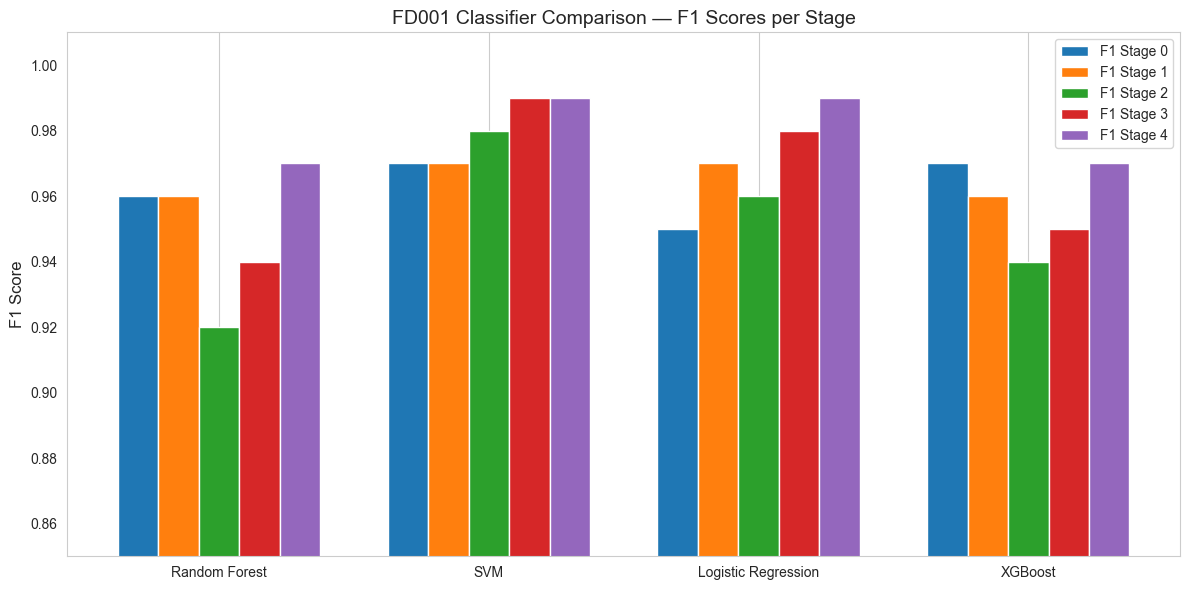

✅ F1 comparison plot saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\fd001_model_f1_scores_by_stage.png


In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# --- Correct Directory Setup ---
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD001')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Metrics from Classification Reports ---
data = {
    'Model': ['Random Forest', 'SVM', 'Logistic Regression', 'XGBoost'],

    # F1 Scores per class
    'F1_Stage_0': [0.96, 0.97, 0.95, 0.97],
    'F1_Stage_1': [0.96, 0.97, 0.97, 0.96],
    'F1_Stage_2': [0.92, 0.98, 0.96, 0.94],
    'F1_Stage_3': [0.94, 0.99, 0.98, 0.95],
    'F1_Stage_4': [0.97, 0.99, 0.99, 0.97],

    # Precision (macro avg)
    'Macro Precision': [0.95, 0.98, 0.96, 0.96],

    # Recall (macro avg)
    'Macro Recall': [0.95, 0.99, 0.98, 0.95],

    # F1 Score (macro avg)
    'Macro F1': [0.95, 0.98, 0.97, 0.96],

    # Weighted Accuracy and CV Scores
    'Test Accuracy': [0.94, 0.99, 0.98, 0.96],
    'CV Mean F1 Score': [0.9423, 0.9822, 0.9748, 0.9535]
}

# --- Save Full Comparison Table ---
df_full = pd.DataFrame(data)
csv_path = os.path.join(REPORT_DIR, 'model_comparison_fd001_all_metrics.csv')
df_full.to_csv(csv_path, index=False)
print(f"✅ Full metrics comparison saved: {csv_path}")

# --- Plot: F1 Scores per Stage ---
f1_cols = ['F1_Stage_0', 'F1_Stage_1', 'F1_Stage_2', 'F1_Stage_3', 'F1_Stage_4']
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.15
x = range(len(df_full))

for i, col in enumerate(f1_cols):
    ax.bar(
        [p + bar_width * i for p in x],
        df_full[col],
        width=bar_width,
        label=col.replace('_', ' ')
    )

ax.set_xticks([p + bar_width * 2 for p in x])
ax.set_xticklabels(df_full['Model'])
ax.set_ylim(0.85, 1.01)
ax.set_ylabel("F1 Score")
ax.set_title("FD001 Classifier Comparison — F1 Scores per Stage")
ax.legend()
ax.grid(axis='y')

# --- Save and Show Plot ---
plot_path_f1 = os.path.join(FIGURES_DIR, 'fd001_model_f1_scores_by_stage.png')
plt.tight_layout()
plt.savefig(plot_path_f1)
plt.show()

print(f"✅ F1 comparison plot saved: {plot_path_f1}")


---
# TEST DATASET

####  Step 9A: Load clean_test_FD001.csv

In [ ]:
# Step 9A – Load clean_test_FD001.csv
import os
import pandas as pd
import joblib

# ✅ Fix: Use os.getcwd() instead of __file__ for Jupyter notebooks
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

# Construct the full path
DATA_PATH = os.path.join(BASE_DIR, 'data', 'clean_test_FD001.csv')

# Load the test dataset
df_test_fd001_raw = pd.read_csv(DATA_PATH)  

# Confirm and preview
print(f"✅ clean_test_FD001.csv loaded from: {DATA_PATH}")
print(df_test_fd001_raw.head())


✅ clean_test_FD001.csv loaded from: c:\Users\pandr\hybrid-predictive-maintenance\data\clean_test_FD001.csv
   unit  time  op_setting_1  op_setting_2  op_setting_3  sensor_2  sensor_3  \
0     1     1        0.0023        0.0003         100.0  0.545181  0.310661   
1     1     2       -0.0027       -0.0003         100.0  0.150602  0.379551   
2     1     3        0.0003        0.0001         100.0  0.376506  0.346632   
3     1     4        0.0042        0.0000         100.0  0.370482  0.285154   
4     1     5        0.0014        0.0000         100.0  0.391566  0.352082   

   sensor_4  sensor_6  sensor_7  sensor_8  sensor_9  sensor_11  sensor_12  \
0  0.269413       1.0  0.652174  0.212121  0.127614   0.208333   0.646055   
1  0.222316       1.0  0.805153  0.166667  0.146684   0.386905   0.739872   
2  0.322248       1.0  0.685990  0.227273  0.158081   0.386905   0.699360   
3  0.408001       1.0  0.679549  0.196970  0.105717   0.255952   0.573561   
4  0.332039       1.0  0.694042  

In [13]:
sensor_cols = [col for col in df_test_fd001_raw.columns if col.startswith("sensor_")]
min_vals = df_test_fd001_raw[sensor_cols].min()
max_vals = df_test_fd001_raw[sensor_cols].max()

print("Minimum values:\n", min_vals)
print("Maximum values:\n", max_vals)


Minimum values:
 sensor_2    -0.024096
sensor_3    -0.043601
sensor_4     0.036124
sensor_6     0.000000
sensor_7     0.165862
sensor_8    -0.015152
sensor_9     0.012564
sensor_11   -0.029762
sensor_12    0.147122
sensor_13    0.014706
sensor_14    0.044174
sensor_15    0.030396
sensor_17    0.083333
sensor_20    0.131783
sensor_21    0.056890
dtype: float64
Maximum values:
 sensor_2     0.930723
sensor_3     0.795945
sensor_4     0.862762
sensor_6     1.000000
sensor_7     0.964573
sensor_8     0.606061
sensor_9     0.598133
sensor_11    0.839286
sensor_12    1.081023
sensor_13    0.647059
sensor_14    0.622046
sensor_15    0.833013
sensor_17    0.750000
sensor_20    0.984496
sensor_21    1.032450
dtype: float64


#### Step 9C – Apply saved KMeans model to test data

In [10]:
import joblib
import os

# Absolute path to your model file
kmeans_model_path = r"C:\Users\pandr\hybrid-predictive-maintenance\data\kmeans_model_FD001.pkl"

# Load the model
kmeans = joblib.load(kmeans_model_path)
print("✅ KMeans model loaded successfully.")


✅ KMeans model loaded successfully.


In [11]:
print("Number of clusters:", kmeans.n_clusters)
print("Cluster centers shape:", kmeans.cluster_centers_.shape)
print("Cluster centers (first 2):\n", kmeans.cluster_centers_[:2])


Number of clusters: 5
Cluster centers shape: (5, 15)
Cluster centers (first 2):
 [[0.50673016 0.47317436 0.52146283 0.99942452 0.50006873 0.35111231
  0.18444011 0.48749692 0.50365966 0.3695061  0.20882903 0.51347967
  0.48268751 0.46304483 0.48314514]
 [0.29966567 0.3076966  0.29232828 0.92503347 0.71651286 0.18493309
  0.18054652 0.23890346 0.75081074 0.20624234 0.22593333 0.30865815
  0.31593039 0.66124224 0.69465109]]


In [12]:
import pandas as pd
import joblib
import numpy as np

# === Paths ===
data_dir = "C:/Users/pandr/hybrid-predictive-maintenance/data"
model_path = f"{data_dir}/kmeans_model_FD001.pkl"
train_data_path = f"{data_dir}/clean_train_FD001.csv"
clustered_data_path = f"{data_dir}/clustered_train_FD001.csv"

# === Load saved KMeans model ===
kmeans = joblib.load(model_path)

# === Load training data and clustered labels ===
clean_train_df = pd.read_csv(train_data_path)
clustered_df = pd.read_csv(clustered_data_path)

# === Extract sensor columns ===
sensor_cols = [col for col in clean_train_df.columns if col.startswith("sensor_")]

# === Predict clusters again using loaded model ===
predicted_clusters = kmeans.predict(clean_train_df[sensor_cols])

# === Compare with saved cluster labels ===
original_clusters = clustered_df["kmeans_cluster"].values
matches = np.sum(predicted_clusters == original_clusters)
total = len(original_clusters)
match_rate = matches / total

# === Output Result ===
print(f"✅ Cluster match: {matches}/{total} → Match Rate: {match_rate:.2%}")

if match_rate == 1.0:
    print("✅ KMeans model loaded correctly — perfect match with original cluster labels.")
else:
    print("⚠️ KMeans model mismatch — the loaded model is not identical to the original.")


✅ Cluster match: 20631/20631 → Match Rate: 100.00%
✅ KMeans model loaded correctly — perfect match with original cluster labels.


### Step 9D: Map KMeans cluster → degradation stage

In [25]:
# Step 9D — Map KMeans cluster to final_stage using saved cluster-to-stage map
import json

# Load cluster → stage mapping
MAP_PATH = os.path.join(BASE_DIR, 'models', 'cluster_to_stage_map_fd001.json')
with open(MAP_PATH, 'r') as f:
    cluster_map = json.load(f)

# Convert keys to int if necessary
cluster_map = {int(k): v for k, v in cluster_map.items()}

# Apply mapping
df_test_fd001_norm['final_stage'] = df_test_fd001_norm['kmeans_cluster'].map(cluster_map)

# Confirm mapping
print("✅ KMeans clusters mapped to final_stage:")
print(df_test_fd001_norm['final_stage'].value_counts().sort_index())


✅ KMeans clusters mapped to final_stage:
final_stage
0    13096
Name: count, dtype: int64


### Step 9E: Load Classifier (RF) and Predict on clean_test_FD001.csv

In [26]:
# Step 9E–9F: Predict using trained Random Forest on test_FD001

import os
import pandas as pd
import joblib
from sklearn.metrics import classification_report

# --- Setup Paths ---
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
MODEL_PATH = os.path.join(BASE_DIR, 'models', 'rf_classifier_fd001.pkl')
TEST_DATA_PATH = os.path.join(BASE_DIR, 'data', 'clean_test_FD001.csv')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD001')
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Load test data ---
df_test_fd001 = pd.read_csv(TEST_DATA_PATH)
sensor_cols = [col for col in df_test_fd001.columns if col.startswith("sensor_")]
X_test = df_test_fd001[sensor_cols]

# --- Load trained Random Forest model ---
rf_model = joblib.load(MODEL_PATH)

# --- Predict ---
y_pred = rf_model.predict(X_test)
proba = rf_model.predict_proba(X_test)
stage4_idx = list(rf_model.classes_).index(4)
prob_stage4 = proba[:, stage4_idx]
confidence = proba.max(axis=1)

# --- Attach predictions to test DataFrame ---
df_test_fd001['predicted_stage'] = y_pred
df_test_fd001['prob_stage4'] = prob_stage4
df_test_fd001['confidence'] = confidence

# --- Save Output ---
output_csv = os.path.join(REPORT_DIR, 'predictions_fd001_rf_test.csv')
df_test_fd001.to_csv(output_csv, index=False)
print(f"✅ Predictions saved to: {output_csv}")


✅ Predictions saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\classification\FD001\predictions_fd001_rf_test.csv


#### Step 9F: SVM Classifier Prediction on Test Data

In [27]:
# SVM Classifier – Prediction on FD001 Test Data
import joblib
import os
import pandas as pd

# Paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
MODEL_PATH = os.path.join(BASE_DIR, 'models', 'svm_classifier_fd001.pkl')
DATA_PATH = os.path.join(BASE_DIR, 'data', 'clean_test_FD001.csv')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD001')
os.makedirs(REPORT_DIR, exist_ok=True)

# Load test data
df_test = pd.read_csv(DATA_PATH)
sensor_cols = [c for c in df_test.columns if c.startswith("sensor_")]
X_test = df_test[sensor_cols]

# Load SVM model and predict
svm_model = joblib.load(MODEL_PATH)
y_pred = svm_model.predict(X_test)
proba = svm_model.predict_proba(X_test)
stage4_idx = list(svm_model.classes_).index(4)
prob_stage4 = proba[:, stage4_idx]
confidence = proba.max(axis=1)

# Save predictions
df_test['predicted_stage'] = y_pred
df_test['prob_stage4'] = prob_stage4
df_test['confidence'] = confidence
df_test.to_csv(os.path.join(REPORT_DIR, 'predictions_fd001_svm_test.csv'), index=False)
print("✅ SVM test predictions saved.")


✅ SVM test predictions saved.


### Step 9F: Logistic Regression Classifier Prediction on Test Data

In [28]:
# Logistic Regression – Prediction on FD001 Test Data
import joblib
import os
import pandas as pd

# Paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
MODEL_PATH = os.path.join(BASE_DIR, 'models', 'logreg_classifier_fd001.pkl')
DATA_PATH = os.path.join(BASE_DIR, 'data', 'clean_test_FD001.csv')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD001')
os.makedirs(REPORT_DIR, exist_ok=True)

# Load test data
df_test = pd.read_csv(DATA_PATH)
sensor_cols = [c for c in df_test.columns if c.startswith("sensor_")]
X_test = df_test[sensor_cols]

# Predict
lr_model = joblib.load(MODEL_PATH)
y_pred = lr_model.predict(X_test)
proba = lr_model.predict_proba(X_test)
stage4_idx = list(lr_model.classes_).index(4)
prob_stage4 = proba[:, stage4_idx]
confidence = proba.max(axis=1)

# Save
df_test['predicted_stage'] = y_pred
df_test['prob_stage4'] = prob_stage4
df_test['confidence'] = confidence
df_test.to_csv(os.path.join(REPORT_DIR, 'predictions_fd001_logreg_test.csv'), index=False)
print("✅ Logistic Regression test predictions saved.")


✅ Logistic Regression test predictions saved.


#### Step 9F: XGBoost Classifier Prediction on Test Data

In [29]:
# XGBoost Classifier – Prediction on FD001 Test Data
import joblib
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
MODEL_PATH = os.path.join(BASE_DIR, 'models', 'xgb_classifier_fd001.pkl')
DATA_PATH = os.path.join(BASE_DIR, 'data', 'clean_test_FD001.csv')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD001')
os.makedirs(REPORT_DIR, exist_ok=True)

# Load data
df_test = pd.read_csv(DATA_PATH)
sensor_cols = [col for col in df_test.columns if col.startswith("sensor_")]
X_test = df_test[sensor_cols]

# Load model and predict
xgb_model = joblib.load(MODEL_PATH)
y_pred_enc = xgb_model.predict(X_test)
proba = xgb_model.predict_proba(X_test)

# Map encoded classes to Stage #
le = LabelEncoder()
le.fit([0, 1, 2, 3, 4])
y_pred = le.inverse_transform(y_pred_enc)
stage4_idx = list(le.classes_).index(4)
prob_stage4 = proba[:, stage4_idx]
confidence = proba.max(axis=1)

# Save
df_test['predicted_stage'] = y_pred
df_test['prob_stage4'] = prob_stage4
df_test['confidence'] = confidence
df_test.to_csv(os.path.join(REPORT_DIR, 'predictions_fd001_xgb_test.csv'), index=False)
print("✅ XGBoost test predictions saved.")


✅ XGBoost test predictions saved.


#### Step 9I: Save Test Misclassifications (If Ground Truth Available)

In [30]:
import pandas as pd
import os

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD001')
os.makedirs(REPORT_DIR, exist_ok=True)

# List of model identifiers
models = ['rf', 'svm', 'logreg', 'xgb']

for model in models:
    path = os.path.join(REPORT_DIR, f'predictions_fd001_{model}_test.csv')
    df = pd.read_csv(path)

    if 'final_stage' in df.columns:
        misclassified = df[df['final_stage'] != df['predicted_stage']]
        misclassified_path = os.path.join(REPORT_DIR, f'misclassified_fd001_{model}_test.csv')
        misclassified.to_csv(misclassified_path, index=False)
        print(f"✅ Misclassified samples saved for {model}: {misclassified_path}")
    else:
        print(f"⚠️ Skipped {model} — 'final_stage' column missing in test file")


⚠️ Skipped rf — 'final_stage' column missing in test file
⚠️ Skipped svm — 'final_stage' column missing in test file
⚠️ Skipped logreg — 'final_stage' column missing in test file
⚠️ Skipped xgb — 'final_stage' column missing in test file
